# Projet 3 : Évaluateur d'engagements RSE pour la détection de greenwashing potentiel (NLP) 

***

***

## 1. Analyse & prétraitement des données

### 1.1. Import des données

Nom du jeu de données : **ML-Promise**. 

On se concentre sur 2 langues : **Français** & **Anglais**

--> Import des données **'Trainset_French.json'** et **Trainset_English.json** pour conversion et fusion en Dataframe

In [1]:
import pandas as pd 

# French df
json_file = '../data/Trainset_French.json'
df_french = pd.read_json(json_file)

# English df
json_file = '../data/Trainset_English.json'
df_english = pd.read_json(json_file)

# Concaténation des 2 df
df = pd.concat([df_french, df_english])
df = df.reset_index(drop=True)
print("Aperçu du début et de la fin du df :")
df.head(-10)

Aperçu du début et de la fin du df :


,URL,page_number,data,promise_status,verification_timeline,evidence_status,evidence_quality
0,https://www.remy-cointreau.com/app/uploads/202...,6,"FOCUS\nEN GRÈCE AVEC KOSTANTINOS KALPAXIDIS,\n...",Yes,Already,Yes,Clear
1,https://www.remy-cointreau.com/app/uploads/202...,7,ACTION 02 /\nOFFRIR LES MEILLEURES CONDITIONS ...,Yes,Already,Yes,Clear
2,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 03 /\nÉTENDRE L’ACTIONNARIAT SALARIÉ\nÀ...,Yes,Already,Yes,Clear
3,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 05 /\nSOUTENIR NOS COMMUNAUTÉS\nET ENGA...,Yes,Already,Yes,Clear
4,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 06 / FORMER TOUS NOS COLLABORATEURS ET ...,Yes,2 to 5 years,Yes,Clear
...,...,...,...,...,...,...,...
785,https://www.standardbank.com/static_file/Stand...,18,Group compliance committee Promotes a complia...,No,N/A,No,N/A
786,https://www.baytexenergy.com/content/uploads/2...,28,"EMPLOYEE SAFETY At Baytex, we are committed to...",Yes,Less than 2 years,No,N/A
787,https://www.baytexenergy.com/content/uploads/2...,28,A safety mindset We promote guidelines that en...,Yes,Already,Yes,Clear
788,https://www.baytexenergy.com/content/uploads/2...,28,Effective systems We maintain high safety stan...,Yes,Already,Yes,Not Clear


--> Dimensions du df

In [2]:
print(df.shape)

(800, 7)


### 1.2. Formatage des données

Encodage numérique des variables (str —> int). Nécessaire car les modèles d’apprentissage prennent en entrée des valeurs numériques et non textuelles.

--> Vérification des labels ppour chaque feature

In [3]:
print('\n')
print('labels distincts de promise_status')
print (df['promise_status'].unique())

print('\n')
print('labels distincts de verification_timeline')
print (df['verification_timeline'].unique())

print('\n')
print('labels distincts de evidence_status')
print (df['evidence_status'].unique())

print('\n')
print('labels distincts de evidence_quality')
print (df['evidence_quality'].unique())



labels distincts de promise_status
['Yes' 'No']


labels distincts de verification_timeline
['Already' '2 to 5 years' 'N/A' 'More than 5 years' 'Less than 2 years'
 '2 to 5 years ']


labels distincts de evidence_status
['Yes' 'No']


labels distincts de evidence_quality
['Clear' 'N/A' 'Not Clear' 'Misleading']


--> Nombre total de rapports contenus dans la base de données d'étude

In [4]:
unique = df['URL'].unique()
print(f"nombre total de rapports contenus dans la base de données : {unique.shape[0]}")

nombre total de rapports contenus dans la base de données : 18


--> Conversion des variables catégorielles en variables numériques

In [5]:
df['promise_status'] = df['promise_status'].map({'Yes': 1, 'No': 0})

df['verification_timeline'] = df['verification_timeline'].map({'Already': 0, 'Less than 2 years': 1, '2 to 5 years': 2, 'More than 5 years': 3,  'N/A': 4})

df['evidence_status'] = df['evidence_status'].map({'Yes': 1, 'No': 0})

df['evidence_quality'] = df['evidence_quality'].map({'Clear': 0, 'Not Clear': 1, 'Misleading': 2, 'N/A': 3})

df.head(5)

,URL,page_number,data,promise_status,verification_timeline,evidence_status,evidence_quality
0,https://www.remy-cointreau.com/app/uploads/202...,6,"FOCUS\nEN GRÈCE AVEC KOSTANTINOS KALPAXIDIS,\n...",1,0.0,1,0
1,https://www.remy-cointreau.com/app/uploads/202...,7,ACTION 02 /\nOFFRIR LES MEILLEURES CONDITIONS ...,1,0.0,1,0
2,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 03 /\nÉTENDRE L’ACTIONNARIAT SALARIÉ\nÀ...,1,0.0,1,0
3,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 05 /\nSOUTENIR NOS COMMUNAUTÉS\nET ENGA...,1,0.0,1,0
4,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 06 / FORMER TOUS NOS COLLABORATEURS ET ...,1,2.0,1,0


--> Verification de la composition des phrases sans "promesse identifiée" (verification si il n'y pas d'élements indésirables t.q. "None")

In [6]:
df_nnn = df[df['promise_status'] == 0]
print(f"Nombre de phrases n'étant pas identifiées comme promesses : {len(df_nnn)}")

df_nnn.head(-10)

Nombre de phrases n'étant pas identifiées comme promesses : 168


,URL,page_number,data,promise_status,verification_timeline,evidence_status,evidence_quality
6,https://www.remy-cointreau.com/app/uploads/202...,8,"FOCUS\nJÉRÔME CANOVAS,\nBRAND DIRECTOR\nPOUR L...",0,4.0,0,3
8,https://www.remy-cointreau.com/app/uploads/202...,9,"«Mon rêve, c’est d’avoir une solution circulai...",0,4.0,0,3
16,https://assets-finance.hermes.com/s3fs-public/...,6,Hermès utilise plus de 35 cuirs différents pou...,0,4.0,0,3
27,https://assets-finance.hermes.com/s3fs-public/...,9,2.4.2.3.3 Cachemire\nLe cachemire est issu de ...,0,4.0,0,3
35,https://www.guerlain.com/on/demandware.static/...,24,TOURNAGE PUBLICITAIRE :\n« Le monde est notre ...,0,4.0,0,3
...,...,...,...,...,...,...,...
771,https://www.standardbank.com/static_file/Stand...,48,Four of the board’s subcommittees are chaired ...,0,4.0,0,3
772,https://www.standardbank.com/static_file/Stand...,48,Margaret Nienaber was promoted to take on the ...,0,4.0,0,3
775,https://www.standardbank.com/static_file/Stand...,19,"Business responsibilities Relevant executives,...",0,4.0,0,3
776,https://www.standardbank.com/static_file/Stand...,19,Group corporate citizenship Reports to CRO De...,0,4.0,0,3


--> Suppression des éléments 'NaN' & Conversion float -> int

In [7]:
# df d'origine
print(f"Type des éléments de la colonne 'verification_timeline'")
print(df["verification_timeline"].dtypes)
print("\n")
print("Labels distincts de 'verification_timeline & décompte'")
print(df["verification_timeline"].unique())
print(df["verification_timeline"].value_counts(dropna=False))

# Suppression des NaN
df = df.dropna(subset=['verification_timeline'])

# Conversion float -> int
df["verification_timeline"] = df["verification_timeline"].astype(int)

# Nouveau df
print("\n")
print('Nouveau type de la colonne & labels distincts')
print(df["verification_timeline"].dtypes)
print(df["verification_timeline"].unique())

Type des éléments de la colonne 'verification_timeline'
float64


Labels distincts de 'verification_timeline & décompte'
[ 0.  2.  4.  3.  1. nan]
verification_timeline
0.0    378
4.0    168
2.0    128
3.0     79
1.0     46
NaN      1
Name: count, dtype: int64


Nouveau type de la colonne & labels distincts
int64
[0 2 4 3 1]


### 1.3. Tokenization du corpus

Afin de nourrir le modèle, il faut d'abord découper le texte en tokens. Chaque tokens est ensuite converti en l'identifiant unique indexé au sein du vacabulaire du tokenizer choisi (langage naturel —> représentation numérique).

##### 1.3.1. Choix du Tokenizer : AutoTokenizer (Fast)


- Utilisation d'un Tokenizer HuggingFace : **AutoTokenizer**
- Version Fast Tokenizer (optimisée en Rust = plus rapide)
- Modèle de pré-entrainé = **"bert-base-multilingual-cased"** (multilingue)

In [8]:
from transformers import AutoTokenizer

# Choix du Tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')

# Vérification que le Tokenizer est "Fast" par défaut
print(f"Fast Tokenizer available: {tokenizer.is_fast}")

/Users/mgerenius/VScode_Workspace/Projets/Projet 03 - Evaluateur_Greenwashing_RSE /.venv_prjct_03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fast Tokenizer available: True


**Test du Tokenizer sur le 1er paragraphe du corpus**


--> Chargement du 1er Paragraphe 

In [9]:
# --- 1er Paragraphe ---

#text_1 = df['data'][0]
text_1 = df['data'][0]
print("Paragraphe 1 :")
print(text_1)
print("\n")

Paragraphe 1 :
FOCUS
EN GRÈCE AVEC KOSTANTINOS KALPAXIDIS,
DEPUTY METAXA MASTER
01/ EN QUOI CONSISTE VOTRE
COLLABORATION AVEC VOS PARTENAIRES
AGRICULTEURS SUR SAMOS?
Nous les conseillons et les accompagnons sur la transition
agroécologique. Sur nos 87 agriculteurs partenaires,
35 nous suivent dans ce programme annuel, qui consiste en
des analyses de leurs sols, l’établissement d’un diagnostic
et la proposition d’améliorations en fonction.
Dans cette logique de transmission, nous faisons intervenir
des experts renommés et animons des réunions très ouvertes
pour recueillir leurs demandes, sur les pratiques à adopter,
les certifications, la feuille de route… Notre légitimité sur
le sujet provient aussi de l’expérimentation que nous
menons au sein de notre Domaine, un vignoble d’1,6 hectare
qui fait office de test et de démonstration pour convaincre
nos partenaires sur l’efficacité de ces pratiques.




--> Tokenization & Affichage des résultats

In [10]:
# --- Tokenization ---

# Conversion du texte en tokens
tokens = tokenizer.tokenize(text_1)

# Conversion en input_ids
input_ids = tokenizer.convert_tokens_to_ids(tokens)

# Préparation des input_ids pour le modèle (ajout de tokens spéciaux si nécessaire)
#inputs_tensor = tokenizer.prepare_for_model(input_ids)

# Pour récuperer uniquement la liste"input_ids" et non un tenseur 1 dim (car 1 seul paragraphe/batch)
encoded = tokenizer(text_1, 
                    add_special_tokens=True, 
                    return_tensors=None)

input_ids = encoded["input_ids"]



# --- Affichage ---

# Paragraphe séparé en tokens
print("Tokens :")
print(tokens)
print("\n")

print("inputs_tensor (1 dim car 1 paragraphe):")
#print(inputs_tensor)
print("\n")

print("input_ids :")
print(input_ids)
print("\n")

print("Longueur du paragraphe :")
print(len(input_ids))

Tokens :
['F', '##OC', '##US', 'EN', 'GR', '##È', '##CE', 'AV', '##EC', 'KO', '##ST', '##AN', '##TI', '##NO', '##S', 'KA', '##L', '##PA', '##X', '##ID', '##IS', ',', 'DE', '##P', '##UT', '##Y', 'ME', '##TA', '##X', '##A', 'MA', '##ST', '##ER', '01', '/', 'EN', 'Q', '##U', '##O', '##I', 'CO', '##NS', '##IS', '##TE', 'V', '##OT', '##RE', 'CO', '##LL', '##A', '##B', '##OR', '##AT', '##ION', 'AV', '##EC', 'V', '##OS', 'PA', '##RT', '##EN', '##A', '##IR', '##ES', 'AG', '##RI', '##C', '##UL', '##TE', '##UR', '##S', 'SU', '##R', 'SAM', '##OS', '?', 'Nous', 'les', 'conseil', '##lons', 'et', 'les', 'ac', '##com', '##pa', '##gnon', '##s', 'sur', 'la', 'transition', 'ag', '##ro', '##éc', '##ologique', '.', 'Sur', 'nos', '87', 'ag', '##ricu', '##lte', '##urs', 'parte', '##naires', ',', '35', 'nous', 'suivent', 'dans', 'ce', 'programme', 'ann', '##uel', ',', 'qui', 'consiste', 'en', 'des', 'analyses', 'de', 'leurs', 'sols', ',', 'l', '[UNK]', 'établissement', 'd', '[UNK]', 'un', 'diagnostic', 'et',

--> Méthode de tokenization simple, retourne un dictionnaire contenant : inputs_ids, tokens_type_ids, attention_mask

In [11]:
tokenizer(text_1)

{'input_ids': [101, 143, 49378, 32612, 31278, 58787, 110910, 43161, 49932, 35826, 67422, 32995, 41275, 72286, 67292, 10731, 85314, 11369, 52099, 12674, 28895, 19088, 117, 25067, 11127, 65729, 14703, 47430, 24951, 12674, 10738, 27277, 32995, 24093, 10669, 120, 31278, 154, 12022, 11403, 11281, 32992, 69196, 19088, 29833, 159, 62146, 66014, 32992, 82834, 10738, 11274, 42622, 32071, 52980, 49932, 35826, 159, 21793, 32349, 46935, 50655, 10738, 73522, 25054, 17935, 46876, 10858, 100673, 29833, 98348, 10731, 86643, 11273, 105508, 21793, 136, 52208, 10152, 24898, 57098, 10131, 10152, 13621, 22530, 11359, 61456, 10107, 10326, 10109, 35959, 16942, 10567, 102063, 69421, 119, 14453, 11573, 12581, 16942, 83696, 17098, 13479, 10552, 38260, 117, 10803, 18354, 101624, 10260, 10794, 19611, 28481, 27043, 117, 10355, 22242, 10110, 10139, 84157, 10104, 14258, 33912, 117, 180, 100, 46615, 172, 100, 10119, 100527, 10131, 10109, 68997, 172, 100, 10392, 107206, 103911, 10110, 24123, 119, 13029, 11464, 109324,

##### 1.3.2. Formatage nécessaire

- Ajout Special Tokens : 
    - [SEP] à la fin de chaque phrase
    - [CLS] au début de chaque phrase
- input_ids : mapping des tokens vers leur index 
- Truncation : découpage de phrases trop longues
    - max_length = 80e percentile de la distribution des longueurs des paragraphes tokenisés
    - sliding windows : pour découpage des paragraphes > max_length
- Padding : Uniformisation de la taille des phrases : 
    - [PAD] (ajout de 0 pour égaliser la taille max définie)
- Attention Mask : Différencie les tokens « vrais mots » [1] des padding [0]

##### 1.3.3. Tokenization avec formatage de l'ensemble du Dataset (Corpus)

Création de fonctions utiles :
- calcul max_length
- tokenization + sliding windows
- création de nouvelles lignes au sein du df afin d'y stocker les paragraphes découpés 

**Définition de Max_length**

--> Calcul de max_lentgh (taille maximale des paragraphes fixée, pour la découpe)

In [12]:
# --- Fonction ---


def paragraphs_max_length(df):
    """
    Calcul du 80e percentile de la distribution des longueurs en tokens. 
    Afin de définir la max_length des séquences
    
    arg : 
    - DataFrame (df) : Pandas DataFrame contenant le corpus d'étude (ensemble des paragraphes) à tokenizer 
    
    return : 
    - percentile_80 = max_length (int) : taille maximum du corpus
    """
    max_len = 0
    min_len = 1000
    list_texts_len = []

    corpus = df['data']

    for text in corpus:
        # Tokenization et attribution des IDs avec les 'special tokens' [CLS] et [SEP] inclus
        input_ids = tokenizer.encode(text, add_special_tokens=True)
        # Comparaison des tailles des paragraphes
        max_len = max(max_len, len(input_ids))  # taille max
        min_len = min(min_len, len(input_ids))  # taille min
        list_texts_len.append(len(input_ids))

    print(f"Taille du paragraphe le plus petit : {min_len}")
    print(f"Taille du paragraphe le plus long : {max_len}")

    # 80e percentile & médiane
    df_quartiles = pd.DataFrame(list_texts_len)
    df_percentile = df_quartiles.quantile([.5, .8])
    mediane = int(df_percentile.iloc[0,0])
    percentile_80 = int(df_percentile.iloc[1,0])
    print(f"Médiane : {mediane}")
    print(f"80e percentile et max_length : {percentile_80}")
    print(f"On fixe donc max_length à : {percentile_80}")

    return percentile_80



# --- Calcul de max_length sur le df ---

max_length = paragraphs_max_length(df=df)

Token indices sequence length is longer than the specified maximum sequence length for this model (608 > 512). Running this sequence through the model will result in indexing errors


Taille du paragraphe le plus petit : 4
Taille du paragraphe le plus long : 1114
Médiane : 163
80e percentile et max_length : 289
On fixe donc max_length à : 289


**Tokenization + sliding windows**

--> Fonction Tokenization d'un paragraphe

In [ ]:
def paragraph_tokenizer(paragraph, max_length, stride):
    """
    Tokenization d'un paragraphe. Conversion d'une chaine de caractères en indentifants tokens.

    args: 
    - paragraph : text à convertir
    - max_length : taille maximum des séquences de caractères
    - stride : découpe des séquences > max_length et création d'une nouvelle séquence

    return :
    - encoded : dictionnaire contenant : input_ids, attention_mask, token_type_ids
    """
    # Tokenization du paragraphe 
    #   Tokenizer : "AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
    #   On a en sortie le dictionnaire "encoded" contenant : input_ids, attention_mask, token_type_ids
    encoded = tokenizer(
                    paragraph,
                    add_special_tokens=True,            # [CLS] & [SEP]
                    max_length=max_length,              # taille max
                    truncation=True,                    # au-delà de max_length, découpage en plusieurs paragraphes 
                    return_overflowing_tokens=True,     # sliding windows --> découpage
                    padding="max_length",               # si len(paragraph) < max_length, ajout de 0 pour égaler max_length
                    stride=stride,                  
                    return_attention_mask = True
    )
    
    return encoded

--> Fonction Tokenization de l'intégralité du Corpus & découpage des grands paragraphes

In [ ]:
def global_tokenizer(df, max_length, stride):
    """
    Tokenize la totalité des paragraphes contenus dans une df passée en revu. 
    Découpage en plusiseurs séquences si la longueur du paragraphe > max_length.

    args: 
    - df : pandas dataframe avec l'ensemble des paragraphes à tokenizer
    - max_length : taille maximum des séquences de caractères
    - stride : découpe des séquences > max_length et création d'une nouvelle séquence

    return :
    - df_tokenized : nouveau df contenant les infos suivnates associées à chaque paragraphes : input_ids, attention_mask, token_type_ids
    """
    
    # Création du nouveau dataset --> liste de pd.Series
    rows = []
    
    # Initialisation d'un compteur du nombre de lignes rajoutées
    counter = 0

    # Itération ligne par ligne (paragraphe par paragraphe)
    for idx, row in df.iterrows():

        # Récupération du paragraphe de la ligne    
        paragraph = row["data"]

        # Tokenization du paragraphe
        encoded = paragraph_tokenizer(paragraph, max_length, stride)

        # Nombre de sliding windows dans 'input_ids' après découpage du paragraphe
        nbr_windows = len(encoded["input_ids"])
        
        if nbr_windows > 1 :
            counter += (nbr_windows - 1)
        # Itération sur les fenêtres de 'input_ids'
        for i in range(nbr_windows):


            # Copie des éléments de la ligne passée en revue dans une pd.Series
            new_row = row.copy()

            # Ajout des nouveaux éléments issus de encoded, avec l'indice i adapté 
            new_row["input_ids"] = encoded["input_ids"][i]
            new_row["attention_mask"] = encoded["attention_mask"][i]
            new_row["token_type_ids"] = encoded["token_type_ids"][i]

            new_row["src_idx"] = idx        # Indéxation avec l'indice d'origine 
            new_row["window_nbr"] = i       # Numéro de la fenêtre passée en revue

            # Ajout des pd.Series une par une dans la liste finale
            rows.append(new_row)

    # Conversion en df pandas
    df_tokenized = pd.DataFrame(rows)
    df_tokenized = pd.DataFrame(rows).reset_index(drop=True)

    print(f"Taille du Dataframe d'origine : {len(df)}")
    print(f"éléments supplémentaires : {counter}")
    print(f"Taille finale du df_tokenized : {len(df_tokenized)}")

    return df_tokenized

**Dataframe tokenizé**

In [15]:
df_tokenized = global_tokenizer(df, max_length=max_length, stride=5)
df_tokenized.head(8)

Taille du Dataframe d'origine : 799
éléments supplémentaires : 181
Taille finale du df_tokenized : 980


,URL,page_number,data,promise_status,verification_timeline,evidence_status,evidence_quality,input_ids,attention_mask,token_type_ids,src_idx,window_nbr
0,https://www.remy-cointreau.com/app/uploads/202...,6,"FOCUS\nEN GRÈCE AVEC KOSTANTINOS KALPAXIDIS,\n...",1,0,1,0,"[101, 143, 49378, 32612, 31278, 58787, 110910,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0
1,https://www.remy-cointreau.com/app/uploads/202...,7,ACTION 02 /\nOFFRIR LES MEILLEURES CONDITIONS ...,1,0,1,0,"[101, 90119, 52980, 10983, 120, 23240, 11565, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,0
2,https://www.remy-cointreau.com/app/uploads/202...,7,ACTION 02 /\nOFFRIR LES MEILLEURES CONDITIONS ...,1,0,1,0,"[101, 10237, 10176, 12091, 10109, 12179, 27920...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,1
3,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 03 /\nÉTENDRE L’ACTIONNARIAT SALARIÉ\nÀ...,1,0,1,0,"[101, 90119, 52980, 10907, 120, 234, 29833, 58...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2,0
4,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 05 /\nSOUTENIR NOS COMMUNAUTÉS\nET ENGA...,1,0,1,0,"[101, 90119, 52980, 10831, 120, 71020, 65729, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,0
5,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 05 /\nSOUTENIR NOS COMMUNAUTÉS\nET ENGA...,1,0,1,0,"[101, 37717, 117, 10794, 181, 102063, 72705, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,1
6,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 06 / FORMER TOUS NOS COLLABORATEURS ET ...,1,2,1,0,"[101, 90119, 52980, 10719, 120, 109544, 42424,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4,0
7,https://www.remy-cointreau.com/app/uploads/202...,8,ACTION 06 / FORMER TOUS NOS COLLABORATEURS ET ...,1,2,1,0,"[101, 93602, 25004, 11573, 18708, 88003, 10171...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4,1


### 1.4. Conversion du dataframe Pandas en Dataset HuggingFace & Nettoyage

--> Conversion df -> HF_dataset

In [16]:
import datasets
from datasets import Dataset

HF_dataset = Dataset.from_pandas(df_tokenized)
HF_dataset

Dataset({
    features: ['URL', 'page_number', 'data', 'promise_status', 'verification_timeline', 'evidence_status', 'evidence_quality', 'input_ids', 'attention_mask', 'token_type_ids', 'src_idx', 'window_nbr'],
    num_rows: 980
})

--> Suppression de certaines colonnes du HF_dataset, inutiles à l'entraînement du modèle

In [17]:
HF_dataset = HF_dataset.remove_columns(["page_number",'URL', 'data','window_nbr','token_type_ids'])
HF_dataset

Dataset({
    features: ['promise_status', 'verification_timeline', 'evidence_status', 'evidence_quality', 'input_ids', 'attention_mask', 'src_idx'],
    num_rows: 980
})

--> Affichage du 1 élément

In [18]:
HF_dataset[1]

{'promise_status': 1,
 'verification_timeline': 0,
 'evidence_status': 1,
 'evidence_quality': 0,
 'input_ids': [101,
  90119,
  52980,
  10983,
  120,
  23240,
  11565,
  46876,
  11273,
  84977,
  10731,
  47430,
  38850,
  51036,
  98348,
  25054,
  32992,
  58521,
  37611,
  52980,
  10731,
  25067,
  80047,
  99903,
  10738,
  38850,
  225,
  180,
  100,
  63992,
  10168,
  45484,
  10131,
  10104,
  11573,
  30016,
  10107,
  117,
  18354,
  11639,
  13396,
  56238,
  10107,
  10152,
  17315,
  10104,
  19358,
  10152,
  10563,
  90974,
  10322,
  11573,
  28552,
  90276,
  82273,
  10107,
  117,
  13000,
  18354,
  66558,
  54325,
  10121,
  171,
  100,
  10176,
  10119,
  11887,
  10525,
  10322,
  22502,
  10104,
  12028,
  118,
  11684,
  10131,
  172,
  100,
  263,
  15119,
  11010,
  59174,
  39143,
  119,
  10243,
  58152,
  117,
  43555,
  27920,
  19156,
  12538,
  10112,
  38508,
  11990,
  10269,
  19505,
  55170,
  10237,
  187,
  100,
  10176,
  11594,
  27920,
  121

In [19]:
type(HF_dataset)

datasets.arrow_dataset.Dataset

### 1.5. Séparation du jeu de données : train / val / test

- Entraînement : 80 %
- Validation : 10 %
- Test : 10 %

On doit séparer le jeu en regroupant fenêtres de paragraphes découpés, afin de ne pas biaiser le modèle et d'augmenter ses performances.

--> Split des données selon src_idx

In [20]:
from sklearn.model_selection import train_test_split

# Train = 0.8 / Val = 0.1 / Test = 0.1

# Récupération des indices uniques
list_src_idx = list(set(HF_dataset['src_idx']))
type(list_src_idx)

# Séparation des indices pour train = 0.8 et le reste = 0.2
train_idx, rest_idx = train_test_split(
    list_src_idx,
    test_size = 0.2,
    random_state=42
)

# Séparation des indices du reste entre validation = 0.5 et test = 0.5
val_idx, test_idx = train_test_split(
    rest_idx,
    test_size = 0.5,
    random_state=42
)

# Séparation du finale du HF_dataset en train / val / test
# On filtre selon les conditions d'appartenance des indices 
train_ds = HF_dataset.filter(lambda x: x["src_idx"] in train_idx)
val_ds = HF_dataset.filter(lambda x: x["src_idx"] in val_idx)
test_ds = HF_dataset.filter(lambda x: x["src_idx"] in test_idx)

Filter: 100%|██████████| 980/980 [00:00<00:00, 10216.84 examples/s]


--> Vérifications

In [21]:
# Vérification qu'aucun élément ne soit présent dans 2 jeux de données différents 
assert set(train_ds["src_idx"]).isdisjoint(val_ds["src_idx"])
assert set(train_ds["src_idx"]).isdisjoint(test_ds["src_idx"])
assert set(val_ds["src_idx"]).isdisjoint(test_ds["src_idx"])
print("OK")

print(f"Taille du train set : {len(train_ds)}")
print(f"Taille du validation set : {len(val_ds)}")
print(f"Taille du test set : {len(test_ds)}")

OK
Taille du train set : 789
Taille du validation set : 95
Taille du test set : 96


***

## 2. Conception, Entraînement & Évaluation du modèle

### 2.1. DataLoaders & Batchs

Dans un premier temps il est nécessaire de convertir des dataset HuggingFace en Tenseur PyTorch

--> Conversion des colonnes en Tenseurs PyTorch pour les jeux train, val, test

In [22]:
# Colonnes à convertir
columns_to_torch=[
    "input_ids",
    "attention_mask",
    #"token_type_ids",
    "promise_status",
    "verification_timeline",
    "evidence_status",
    "evidence_quality",
]

# Train
train_ds.set_format(
    type="torch",
    columns=columns_to_torch
)

# Eval
val_ds.set_format(
    type="torch",
    columns=columns_to_torch
)

# Test
test_ds.set_format(
    type="torch",
    columns=columns_to_torch
)

--> Vérification d'un élément

In [23]:
row_1 = train_ds[0]

print(type(row_1['input_ids']))
print(type(row_1['verification_timeline']))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


Les DataLoaders permettent d'itérer sur les batchs (entraînement et évaluation)

--> Création des Dataloaders pour les Batchs d'entraînement

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)

eval_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=True
)

--> Affichage du premier batch

In [25]:
batch = next(iter(train_loader))
batch

{'promise_status': tensor([1, 0, 1, 1, 0, 1, 1, 0]),
 'verification_timeline': tensor([2, 4, 0, 3, 4, 0, 0, 4]),
 'evidence_status': tensor([1, 0, 1, 1, 0, 1, 1, 0]),
 'evidence_quality': tensor([0, 3, 1, 0, 3, 0, 0, 3]),
 'input_ids': tensor([[  101, 11841, 13253,  ...,     0,     0,     0],
         [  101, 20569, 36789,  ...,     0,     0,     0],
         [  101,   127,   119,  ...,     0,     0,     0],
         ...,
         [  101,   149,   100,  ..., 10139, 42621,   102],
         [  101, 11514, 10142,  ...,     0,     0,     0],
         [  101,   125,   120,  ...,     0,     0,     0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]])}

--> Dimensions et composition d'un Batch

In [26]:
for batch in train_loader:
    break
{k: v.shape for k, v in batch.items()}

{'promise_status': torch.Size([8]),
 'verification_timeline': torch.Size([8]),
 'evidence_status': torch.Size([8]),
 'evidence_quality': torch.Size([8]),
 'input_ids': torch.Size([8, 289]),
 'attention_mask': torch.Size([8, 289])}

### 2.2. Pipeline d'apprentissage

L'objectif est ici de produire un pipeline capable de sortir pour 1 paragraphe d'entrée, 4 sorties distinctes :
- promise_status : {0, 1}  --> classification binaire
- verification_timeline : {0, 1, 2, 3, 4}   --> classification multi-classe
- evidence_status {0, 1}   --> classification binaire
- evidence_quality {0, 1, 2, 3}   --> classification multi-classe

Pour cela, il faut implémenter un Classifieur Multi-tâches hétérogène, par fine-tuning d'un modèle existant.

##### 2.2.1. Architecture du Pipeline

Modèle pré-entraîné : bert-base-multilingual-cased
- hidden_size = 768
- num_hidden_layers = 12
- num_attention_heads = 12

--> Modèle BERT MultiTasks Classifier

In [27]:
import torch
import torch.nn as nn
from transformers import AutoModel



class BERT_MultiTask_Classifier(nn.Module):


    def __init__(self):
        """
        Initialise l'architecture du modèle multi-tâches basé sur BERT.

        Le modèle repose sur un encodeur pré-entrainé BERT multilingue "bert-base-multilingual-cased".

        À partir de la représentation vectorielle du token [CLS] issu de l'encodeur pricipal (Embedding),
        4 têtes de classifications indépendantes sont définies pour prédire :
        - promise_status : 2 classes
        - verification_timeline : 5 classes
        - evidence_status : 2 classes
        - evidence_quality :  4 classes
        """
        super().__init__()
        # Chargement de l'Encoder pré-entraîné BERT 
        self.bert = AutoModel.from_pretrained("bert-base-multilingual-cased")               # Précision du modèle exact
        # Têtes de classification avec config. BERT                     
        self.head_promise_status_classifier = nn.Linear(self.bert.config.hidden_size, 2)    # tête de classifcation 2 classes
        self.head_timeline_classifier = nn.Linear(self.bert.config.hidden_size, 5)          # tête de classifcation 5 classes
        self.head_evidence_status_classifier = nn.Linear(self.bert.config.hidden_size, 2)   # tête de classifcation 2 classes
        self.head_evidence_quality_classifier = nn.Linear(self.bert.config.hidden_size, 4)  # tête de classifcation 4 classes
        # Régularisation Dropout -> limite le sur-apprentissage
        self.dropout = nn.Dropout(0.3)                                                      # 30% des neurones sont désactivés       


    def forward(self, input_ids, attention_mask, 
                promise_status=None, 
                verification_timeline=None, 
                evidence_status=None, 
                evidence_quality=None):
        """
        Définition de la procédure d'apprentissage (du comportement) du modèle. 
        Permet d'obtenir les prédictions (logits) et de calculer la fonction de perte (Loss)
                
        args:
        - input_ids (torch.Tensor) : tensor contenant les identifiants des tokens
        - attention_mask (torch.Tensor)

        returns:
        - Dictionnaire contenant :
            - "loss" (torch.Tensor) : Loss totale (somme des losses des 4 tâches)
            - "logits" (torch.Tensor) : Tuple contenant les logits pour chaque tâche dans l’ordre : (promise_status, verification_timeline, evidence_status, evidence_quality)
        """
        
        # Récupération des sorties produites par Encoder BERT
        outputs = self.bert(input_ids, attention_mask=attention_mask)

        # Récupération du CLS_token de dim (B, E) (voir notes) + Dropout
        CLS_token = outputs.last_hidden_state[:, 0, :]
        CLS_token = self.dropout(CLS_token)

        # Chaque tête de classifcation prend en entrée CLS_token
        logits_promise_status = self.head_promise_status_classifier(CLS_token)
        logits_timeline = self.head_timeline_classifier(CLS_token)
        logits_evidence_status = self.head_evidence_status_classifier(CLS_token)
        logits_evidence_quality = self.head_evidence_quality_classifier(CLS_token)
        
        # Fonctions de perte pour chaque tête (CrossEntropy)
        # En prévision de la phase d'inférence, il est nécessaire de rendre cette étape conditionnelle, afin d'éviter le crash du modèle.
        # En effet, en phase d'inférence, une phrase passée en argument n'a pas de labels associés et donc les logits sont par défaut = None --> cause d'erreur
    
        # Initialisation de la loss globale à None par défaut
        total_loss = None
        # Calcul des fonctions de perte seulement si des labels existent
        if promise_status is not None:
            # Comparaison entre sorties prédites et labels réels
            loss_fct = nn.CrossEntropyLoss()
            loss_promise_status = loss_fct(logits_promise_status, promise_status)
            loss_timeline = loss_fct(logits_timeline, verification_timeline)
            loss_evidence_status = loss_fct(logits_evidence_status, evidence_status)
            loss_evidence_quality = loss_fct(logits_evidence_quality, evidence_quality)
            # Somme des losses
            total_loss = loss_promise_status + loss_timeline + loss_evidence_status + loss_evidence_quality
 
        # Retourne les logits prédits & des loss de chaque tête
        return {
            # Loss totale
            "loss": total_loss,
            # Logits
            "logits": (
                logits_promise_status,
                logits_timeline,
                logits_evidence_status,
                logits_evidence_quality
            )
        }



my_model = BERT_MultiTask_Classifier()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6622.08it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Arguments nécessaires au Trainer

In [28]:
from transformers import TrainingArguments


train_args = TrainingArguments(
    output_dir="./training_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,                     # valeur stable
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,                     # bon compromis
    weight_decay=0.01,                      # régularisation L2 contre overfitting
    logging_dir="./logs",                   # dossier sauvegarde logs (losses, metrics, lr)
    logging_steps=10,                       # fréquence d'affichage de la loss
    load_best_model_at_end=True,            # checkpoint (epoch) avec meilleurs résultats
    metric_for_best_model="eval_loss",
    use_cpu=True,                           # Afin d'utiliser GPU Apple Silicone (MPS)
    report_to=[]                            # Désactive TensorBoard / les callbacks (sources d'erreur)
    label_names=[
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
    ]
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


--> Métriques

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np


def compute_metrics(eval_pred):
    """
    Calcul des métriques utiles à l'évaluation de l'entraînement.

    return :
    - Dictionnaire : contenant les valeurs de score F1 et précision (accuracy) associés à chaque tâche de classification
    """
    
    # Le Trainer renvoie la variable "eval_pred"
    logits = eval_pred.predictions
    labels = eval_pred.label_ids

    # Affichage des dimensions et de la nature des composantes de "eval_pred"
    # print("TYPE predictions:", type(eval_pred.predictions))
    # print("TYPE labels:", type(eval_pred.label_ids))
    # print("LEN predictions:", len(eval_pred.predictions))
    # print("LEN labels:", len(eval_pred.label_ids))

    # Récupération des logits
    logits_promise_status = logits[0]
    logits_timeline = logits[1]
    logits_evidence_status = logits[2]
    logits_evidence_quality = logits[3]

    # Récupération des labels
    labels_promise_status = labels[0]
    labels_timeline = labels[1]
    labels_evidence_status = labels[2]
    labels_evidence_quality = labels[3]

    # Conversion des logits en pred
    pred_promise_status = np.argmax(logits_promise_status, axis=1)
    pred_timeline = np.argmax(logits_timeline, axis=1)
    pred_evidence_status = np.argmax(logits_evidence_status, axis=1)
    pred_evidence_quality = np.argmax(logits_evidence_quality, axis=1)

    # Accuracy : comparaison pred vs labels
    acc_promise_status = accuracy_score(labels_promise_status, pred_promise_status)
    acc_timeline = accuracy_score(labels_timeline, pred_timeline)
    acc_evidence_status = accuracy_score(labels_evidence_status, pred_evidence_status)
    acc_evidence_quality = accuracy_score(labels_evidence_quality, pred_evidence_quality)

    # F1 score : évaluation performance du modèle ("macro f1" permet de donner performance équilibrer malgrer les classes désiquilibrées)
    f1_promise_status = f1_score(labels_promise_status, pred_promise_status, average="macro")
    f1_timeline = f1_score(labels_timeline, pred_timeline, average="macro")
    f1_evidence_status = f1_score(labels_evidence_status, pred_evidence_status, average="macro")
    f1_evidence_quality = f1_score(labels_evidence_quality, pred_evidence_quality, average="macro")

    return {
        'acc_promise_status': acc_promise_status,
        'acc_timeline': acc_timeline,
        'acc_evidence_status': acc_evidence_status,
        'acc_evidence_quality': acc_evidence_quality,

        'f1_promise_status': f1_promise_status, 
        'f1_timeline': f1_timeline,
        'f1_evidence_status': f1_evidence_status,
        'f1_evidence_quality': f1_evidence_quality
    }

--> Trainer. 

Permet de Fine-tuner le modèle pré-entraîné choisi (BERT), avec le jeu de données ML et les hyper-paramètres définis

In [30]:
from transformers import Trainer

trainer = Trainer(
    model=my_model,
    args=train_args,
    train_dataset = train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

--> Vérification de la disponibilité de MPS (GPU Apple Silicone)

In [31]:
# Si "True" --> C'est bon
print(torch.backends.mps.is_available())

True


##### 2.2.1. Evaluation de l'architecture sur 1 batch

--> Isolement d'un batch

In [32]:
batch = train_ds[0]

for key in batch:
    batch[key] = batch[key].unsqueeze(0)  # ajoute batch dim

outputs = my_model(**batch)

print(outputs["loss"])

print(batch["verification_timeline"].dtype)

tensor(5.6041, grad_fn=<AddBackward0>)
torch.int64


### 2.3. Entraînement

##### 2.3.1. Phase d'entraînement

--> Entraînement du modèle final  :
 - Entaînement : train_ds 
 - Évaluation à chaque epoch : val_ds

In [33]:
trainer.train()
print("Entraînement terminé ✅")

Epoch,Training Loss,Validation Loss,Acc Promise Status,Acc Timeline,Acc Evidence Status,Acc Evidence Quality,F1 Promise Status,F1 Timeline,F1 Evidence Status,F1 Evidence Quality
1,3.369257,3.174597,0.831579,0.505263,0.715789,0.610526,0.618474,0.241218,0.646743,0.318317
2,3.139220,3.182096,0.821053,0.505263,0.705263,0.568421,0.735636,0.254810,0.695513,0.345808
3,2.273501,3.039305,0.873684,0.547368,0.757895,0.621053,0.748677,0.331843,0.699077,0.359923
4,1.380794,3.044690,0.884211,0.547368,0.747368,0.652632,0.798301,0.332174,0.717262,0.420402
5,1.440758,3.146843,0.852632,0.547368,0.747368,0.610526,0.722917,0.349333,0.702194,0.414994


Entraînement terminé ✅


##### 2.3.2. Sauvegardes du modèle entraîné & des Logs (métriques) 

--> Version du modèle

In [34]:
model_name = "model_V3"

--> Sauvegarde des logs d'entraînement sous forme de tableau CSV

In [35]:
# Récupération des l'historique et conversion en df
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)
df_logs.to_csv(f"../saved_models/{model_name}/training_logs_tab.csv", index=False)
print("Logs sauvegardés ✅")

Logs sauvegardés ✅


--> Sauvegarde du modèle & tokenizer

In [36]:
# Sauvegarde du modèle et du tokenizer associé
trainer.save_model(f"../saved_models/{model_name}")
tokenizer.save_pretrained(f"../saved_models/{model_name}")
print("Modèle & tokenizer sauvegardés ✅")

Modèle & tokenizer sauvegardés ✅


##### 2.3.3. Chargement du modèle sauvegardé

--> Pour ne pas réentraîner le modèle, on charge la sauvegarde locale

In [37]:
from safetensors.torch import load_file

# Recréation de l'architecuture
my_final_model = BERT_MultiTask_Classifier()

# Chargement des poids
state_dict = load_file(f"../saved_models/{model_name}/model.safetensors")
my_final_model.load_state_dict(state_dict)

# Vérification que tout est OK
missing, unexpected = my_final_model.load_state_dict(state_dict, strict=False)

# Si vide --> OK
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

print("Modèle entraîné rechargé ✅")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4174.10it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Missing keys: []
Unexpected keys: []
Modèle entraîné rechargé ✅


##### 2.3.4. Graphique d'entraînement

--> Loss Train & Loss Val

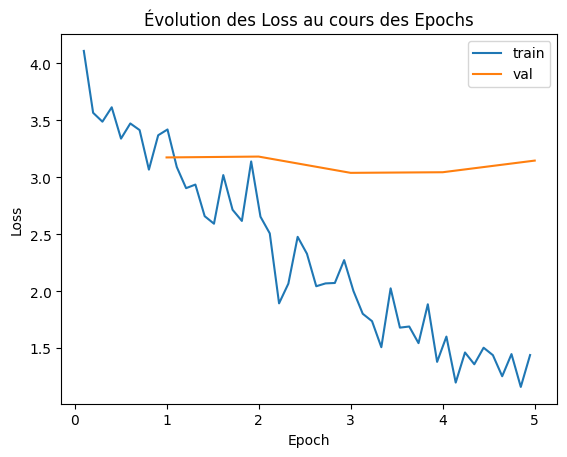

In [38]:
import matplotlib.pyplot as plt


# Import de la sauvegarde des logs
df_logs = pd.read_csv(f"../saved_models/{model_name}/training_logs_tab.csv")

train_df = df_logs[df_logs["loss"].notna()]
eval_df = df_logs[df_logs["eval_loss"].notna()]

# Affichage
plt.plot(train_df["epoch"], train_df["loss"], label="train")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="val")

plt.legend()
plt.title("Évolution des Loss au cours des Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### 2.5. Évaluation

--> Pour éviter les problèmes de Callbacks (optionnel)

In [39]:
# Sauvegarde les callbacks originaux
original_callbacks = trainer.callback_handler.callbacks

# Retrait les callbacks problématiques
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks 
    if not cb.__class__.__name__ == 'NotebookProgressCallback'
]

##### 2.4.1. Données de validation

In [40]:
trainer.evaluate(val_ds)

{'eval_loss': 3.0393049716949463,
 'eval_acc_promise_status': 0.8736842105263158,
 'eval_acc_timeline': 0.5473684210526316,
 'eval_acc_evidence_status': 0.7578947368421053,
 'eval_acc_evidence_quality': 0.6210526315789474,
 'eval_f1_promise_status': 0.7486772486772486,
 'eval_f1_timeline': 0.3318426501035197,
 'eval_f1_evidence_status': 0.6990772620851122,
 'eval_f1_evidence_quality': 0.3599234742402294,
 'eval_runtime': 6.783,
 'eval_samples_per_second': 14.006,
 'eval_steps_per_second': 1.769,
 'epoch': 5.0}

##### 2.4.2. Données Test

In [41]:
trainer.evaluate(test_ds)

{'eval_loss': 2.643413782119751,
 'eval_acc_promise_status': 0.90625,
 'eval_acc_timeline': 0.6041666666666666,
 'eval_acc_evidence_status': 0.8229166666666666,
 'eval_acc_evidence_quality': 0.6770833333333334,
 'eval_f1_promise_status': 0.8427661510464058,
 'eval_f1_timeline': 0.3122291021671827,
 'eval_f1_evidence_status': 0.7784715623727433,
 'eval_f1_evidence_quality': 0.44564222742997434,
 'eval_runtime': 7.0644,
 'eval_samples_per_second': 13.589,
 'eval_steps_per_second': 1.699,
 'epoch': 5.0}

##### 2.4.3. Graphiques d'Évaluation

--> Matrices de confusion

Les matrices de confusion permettent de voir pour chaque tâches de classification, sur quelles classes spécifiques le modèle effectues de bonnes prédictions ou se trompe.

Matrices de confusion générés et sauvegardées à l'emplacement : ../figures/confusion_matrices.png


<Figure size 640x480 with 0 Axes>

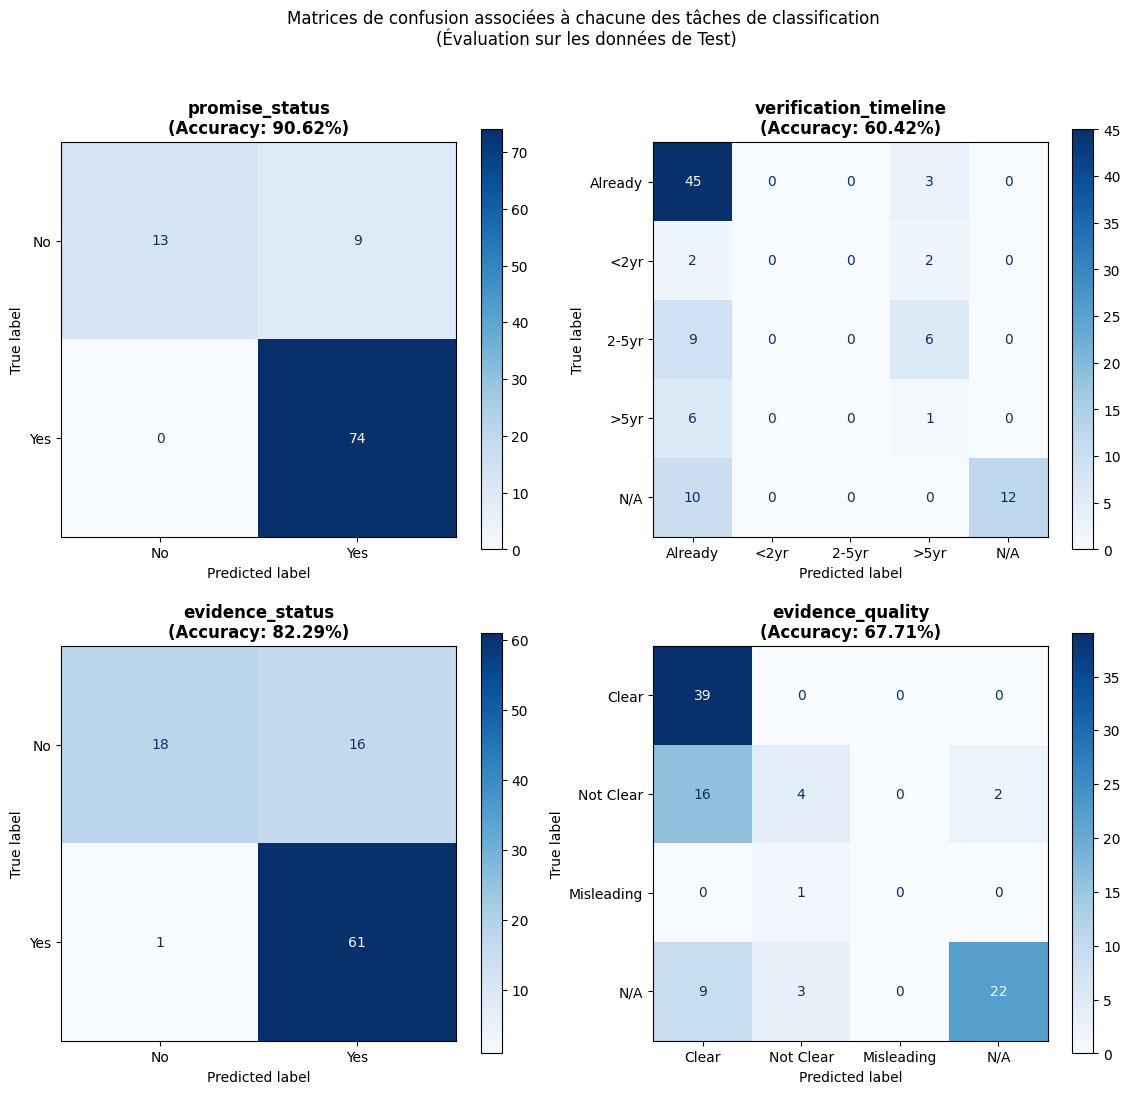

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



def confusion_matrices(trainer, test_ds, model_name):
    """
    Génère la matrice de confusion associée à chacune des tâches de classification.

    args :
    - trainer : paramètres de l'entraînement
    - test_ds : dataset évalué, ici données Test
    - model_name : modèle utilisé

    return :
    - figures
    """
    
    # --- Prédictions sur données de Test --- 
    predictions = trainer.predict(test_ds)
    logits = predictions.predictions
    labels_true = predictions.label_ids
    
    task_names = ['promise_status', 'verification_timeline', 
                  'evidence_status', 'evidence_quality']
    task_labels = [
        ['No', 'Yes'],                                  # promise
        ['Already', '<2yr', '2-5yr', '>5yr', 'N/A'],    # timeline
        ['No', 'Yes'],                                  # evidence
        ['Clear', 'Not Clear', 'Misleading', 'N/A']     # quality
    ]

    
    # --- Matrice de confusion ---
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for i, (ax, task, labels) in enumerate(zip(axes, task_names, task_labels)):
        # Convertir logits --> prédictions
        preds = np.argmax(logits[i], axis=1)
        true = labels_true[i]
        
        # Calcul de la matrice
        cm = confusion_matrix(true, preds)
        
        # Affichage
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.close('all')
        ax.set_title(f'{task}\n(Accuracy: {(cm.diagonal().sum() / cm.sum()):.2%})', 
                     fontsize=12, fontweight='bold')
        ax.grid(False)
    
    fig.suptitle("Matrices de confusion associées à chacune des tâches de classification \n(Évaluation sur les données de Test)")
    plt.tight_layout()
    
    # Sauvegarde et affichage
    save_path = f"../figures/confusion_matrices.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Matrices de confusion générés et sauvegardées à l'emplacement : {save_path}")
    plt.show()
    
    return fig


# --- Appelle de la fonction ---
confusion_matrices(trainer, test_ds, model_name="model_V3")

--> Comparaison Scores-F1 entre dataset Train/Val/Test

Permet de visualiser les performances du modèle sur chaque tâche de classification, entre les différents datasets

Scores-F1 calculés et sauvegardés à l'emplacement : ../figures/F1-Scores.png


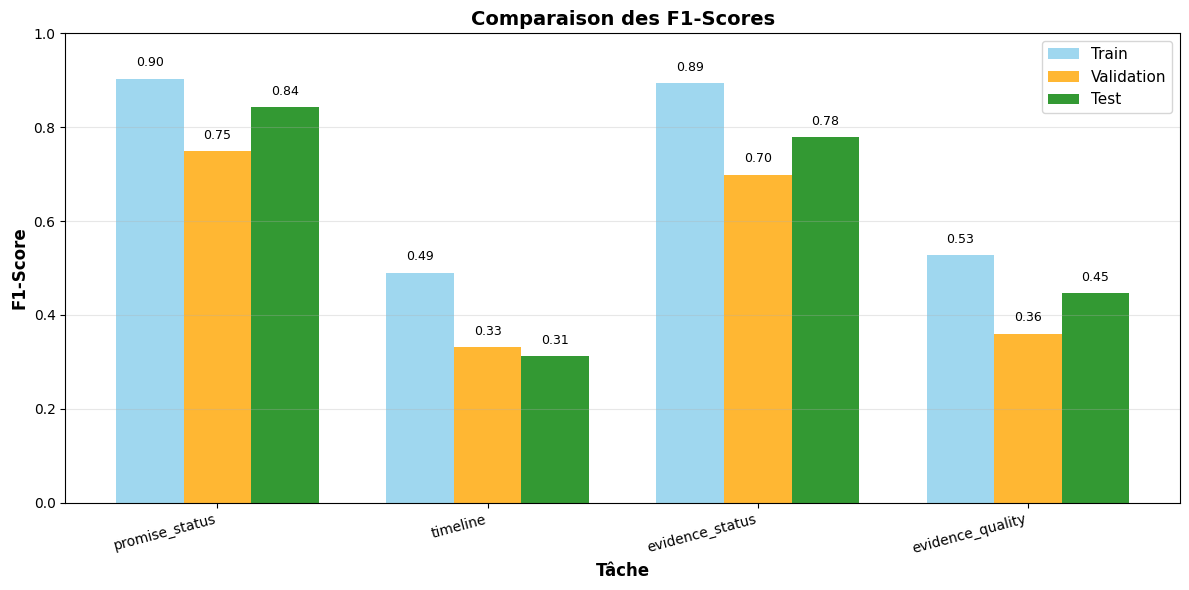


Résumé des F1-Scores :

            Task    Train  Validation     Test
  promise_status 0.903076    0.748677 0.842766
        timeline 0.489775    0.331843 0.312229
 evidence_status 0.893682    0.699077 0.778472
evidence_quality 0.527660    0.359923 0.445642


In [73]:
def f1_comparison(trainer, train_ds, val_ds, test_ds, model_name):
    """
    Comparaison du score f1 pour chaque tâche, entre les différents datasets

    args :
    - trainer
    - datatsets :
        - Train
        - Val
        - Test
    - Model :  modèle évalué

    return :
    - figure
    - dataframe : tableau des valeurs de score-F1
    """
    
    
    # --- Calcul de scores --- 

    # Évaluation sur les 3 datasets Train / Val / Test
    train_metrics = trainer.evaluate(train_ds)
    val_metrics = trainer.evaluate(val_ds)
    test_metrics = trainer.evaluate(test_ds)
    
    # Extraction des F1-scores pour chaque tâche
    tasks = ['promise_status', 'timeline', 'evidence_status', 'evidence_quality']
    
    f1_data = {
        'Task': tasks,
        'Train': [
            train_metrics['eval_f1_promise_status'],
            train_metrics['eval_f1_timeline'],
            train_metrics['eval_f1_evidence_status'],
            train_metrics['eval_f1_evidence_quality']
        ],
        'Validation': [
            val_metrics['eval_f1_promise_status'],
            val_metrics['eval_f1_timeline'],
            val_metrics['eval_f1_evidence_status'],
            val_metrics['eval_f1_evidence_quality']
        ],
        'Test': [
            test_metrics['eval_f1_promise_status'],
            test_metrics['eval_f1_timeline'],
            test_metrics['eval_f1_evidence_status'],
            test_metrics['eval_f1_evidence_quality']
        ]
    }
    
    df_f1 = pd.DataFrame(f1_data)
    

    # --- Affichage ---

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(tasks))
    width = 0.25
    
    ax.bar(x - width, df_f1['Train'], width, label='Train', alpha=0.8, color='skyblue')
    ax.bar(x, df_f1['Validation'], width, label='Validation', alpha=0.8, color='orange')
    ax.bar(x + width, df_f1['Test'], width, label='Test', alpha=0.8, color='green')
    
    ax.set_xlabel('Tâche', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax.set_title('Comparaison des F1-Scores', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(tasks, rotation=15, ha='right')
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Ajout des valeurs sur les barres
    for i, task in enumerate(tasks):
        ax.text(i - width, df_f1['Train'][i] + 0.02, f"{df_f1['Train'][i]:.2f}", 
                ha='center', va='bottom', fontsize=9)
        ax.text(i, df_f1['Validation'][i] + 0.02, f"{df_f1['Validation'][i]:.2f}", 
                ha='center', va='bottom', fontsize=9)
        ax.text(i + width, df_f1['Test'][i] + 0.02, f"{df_f1['Test'][i]:.2f}", 
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Génération et sauvegarde
    save_path = f"../figures/F1-Scores.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Scores-F1 calculés et sauvegardés à l'emplacement : {save_path}")
    plt.show()
    
    # Affichage du tableau résumé
    print("\nRésumé des F1-Scores :\n")
    print(df_f1.to_string(index=False))
    
    return fig, df_f1



# --- Appel de la fonction ---
fig, df = f1_comparison(trainer, train_ds, val_ds, test_ds, "model_V3")

***

## 3. Inférence du modèle & Score de greenwashing : Prédictions

### 3.1. Fonction d'inférence

On utilise le modèle entraîné sur les données de Train, pour faire inférence sur les données de Test et prédire les labels associés à chaque phrase

--> Fonction d'inférence / Prédiction des labels

In [ ]:
# nécessaire pour Softmax
import torch.nn.functional as F


def predict_labels(text, model, tokenizer, device="cpu"):
    """
    Fonction d'inférence permettant d'effectuer une prédiction multi-tâches sur un paragraphe

    args :
    - text :  paragraphe d'étude
    - model : modèle entraîné sélectionné pour faire l'inférence
    - tokenizer : tokenizer utilisé pour convertir le text brutes en tokens à fournir au modèle
    - device : ici, envoie les calculs le CPU

    return :
    - pred : label (classe) prédit pour chaque tâche de classification
    - proba : pour chaque tâche (avec n classes), n probabilités prédites associées à chaque classes 
    - dict_results : dictionnaire contenant l'ensemble des proba et prédiction
    """


    #--- Configuration ---
    # Mise en mode "inférence" du modèle (désactive le Dropout / stabilise les résultats)
    model.eval()

    # Usage du modèle sur CPU
    model.to(device)


    #--- Inférence ---

    # Tokenization
    inputs = tokenizer(
        text,
        return_tensors="pt",      # "pt" = Pytorch Tensor
        padding='max_length',
        max_length=max_length     # max_length a été défini plus haut par la fonction "paragraphs_max_length()"
    )
    # Suppression des éléments 'token_type_ids' car pas recevable par le modèle
    inputs.pop("token_type_ids", None)

    # Envoi des inputs sur le device = CPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Précison au modèle de ne pas calculer les gradients (permets de d'économiser du temps et de la mémoire)
    with torch.no_grad():
        # Passage des entrées dans le modèle & prédiction des sorties
        outputs = model(**inputs)

    # Récupération des logits parmi le dictionnaire de sorties
    logits = outputs["logits"]

    # Conversion sorties : Logits --> Probabilités (usage de Softmax)
    probas = [F.softmax(l, dim=1)[0].cpu().numpy() for l in logits]
    
    # Conversion : probabilités --> Prédictions  (usage argmax) 
    preds = [int(np.argmax(p)) for p in probas]


    #--- Sorties ---

    # Dictionnaire des labels prédits et probabilités associées
    dict_results = {}
    keys = [
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
        ]
    
    print("---------------------\n")
    print("Inférence terminée...\n")
    print("PRÉDICTIONS & PROBABILITÉS associées :\n")
    
    for i, key in enumerate(keys):
        label = preds[i]
        proba = probas[i][preds[i]]
        dict_results[key] = {
           "label": label,
            "probabilité": float(proba)
        }
        print(f"{key} : {dict_results[key]}\n")
    
    print("---------------------\n")
    print("Prédictions & Probabilitées détaillées :\n")
    
    print(preds, "\n")
    print(probas,"\n")

    return probas, preds, dict_results

### 3.2. Score de Greenwashing

--> Fonction de Score de Greenwashing

In [ ]:
def greenwashing_score(text, model, tokenizer):
    """
    Calcul le score de risque potentiel de greenwashing asssocié à un paragraphe donné.
    Méthode de calcul hubride : règles + pondération probabiliste.
    - 0 --> risque faible
    - 100 --> risque très élevé

    args :
        - text :  paragraphe d'étude
        - model : modèle entraîné sélectionné pour faire l'inférence
        - tokenizer : tokenizer utilisé pour convertir le text brutes en tokens à fournir au modèle

    return :
    - SCORE : score de greenwashing potentiel
    
    """
    
    #--- Appel de la fonction de prediction des labels ---

    probas, preds, dict_results = predict_labels(text, model, tokenizer)


    #--- Procédure de calcul du SCORE ---

    # verification_timeline
    reward_timeline = []
    # Label 0 : Already
    rwd_label = 100 * probas[1][0]          # +100 pts pondérés
    reward_timeline.append(rwd_label)
    # Label 1 : Less than 2 years
    rwd_label = 90 * probas[1][1]           # +90 pts pondérés
    reward_timeline.append(rwd_label)
    # Label 2 : 2 to 5 years
    rwd_label = 80 * probas[1][2]           # +80 pts pondérés
    reward_timeline.append(rwd_label)
    # Label 3 : More than 5 years
    rwd_label = 50 * probas[1][3]           # +50 pts pondérés
    reward_timeline.append(rwd_label)
    # Label 4 : N/A
    reward_timeline.append(0)               # +0 pts

    # evidence_status
    reward_evidence = []
    # Label 0 : No
    reward_evidence.append(0)               # +0 pts
    # Label 1 : Yes
    rwd_label = 100 * probas[2][1]          # +100 pts pondérés
    reward_evidence.append(rwd_label)

    # evidence_quality
    reward_quality = []
    # Label 0 : Clear
    rwd_label = 100 * probas[3][0]          # +100 pts pondérés
    reward_quality.append(rwd_label)
    # Label 1 : Not clear
    rwd_label = 40 * probas[3][1]           # +40 pts pondérés
    reward_quality.append(rwd_label)
    # Label 2 : Misleading
    reward_quality.append(0)                # +0 pts 
    # Label 3 : N/A
    rwd_label = 30 * probas[3][3]           # +30 pts pondérés
    reward_quality.append(rwd_label)

    # SCORE total
    sum_reward_timeline = sum(reward_timeline)
    sum_reward_evidence = sum(reward_evidence)
    sum_reward_quality = sum(reward_quality)
    total_score = sum_reward_timeline + sum_reward_evidence + sum_reward_quality
    # Normalisation du score par 300 (car 300 = Max de points cumulables)) et converversion en pourcentage (*100/300 = 1/3)
    max_score = 3
    # ici on veut : SCORE ++ --> RISQUE GREENWASHING ++
    SCORE = round((100 - (total_score) / max_score), 2)        # On arrondi au centième, normalise, rapport en pourcentage et inverse



    #--- Influence de l'identifiaction ou non de promesse 

    # Récupération des prédiction et proba d'identification de promesse 'promise_status' : oui (1) ou non (0)
    pred_promise_status = preds[0]
    proba_promise_satus = probas[0][1]

    # Si pred_promise_status = 0 (= proba_promise_status < .5) --> SCORE est pondéré par cette proba
    if pred_promise_status == 0:
        SCORE = SCORE * proba_promise_satus



    #--- Affichage final ---
    print("---------------------\n")
    print(f'SCORE DE RISQUE DE GREENWASHING : {SCORE}%')
    print("\n---------------------\n")


    return SCORE

### 3.3. Cas d'usage concret sur extraits de rapport RSE

##### 3.3.1. Usage sur extrait issu des données de Test

--> Évaluation de la fonction d'inférence sur un exemple issu des données de Test

In [47]:
text = "Par ailleurs, une attention particulière est portée aux règles de biosécurité dans les fermes, aﬁn de protéger les élevages de l’introduction d’agents infectieux. Cela se traduit notamment par le respect d’exigences strictes lors des transferts d’animaux sur les fermes ou entre les fermes, la mise en place d’instructions de désinfection et de programmes de lutte antiparasitaire ou de vaccination des animaux. Ces différents protocoles ont été établis en collaboration avec des vétérinaires spécialisés dans les espèces concernées. Ainsi en 2022, la totalité des tanneries Hcp sont membres de l’ICFA et 99,3 % des peaux brutes de crocodiliens achetées par le pôle Tanneries proviennent de fermes ayant fait l’objet d’un audit externe par Bureau Veritas ou BSI dans le cadre de la certiﬁcation ICFA."

predict_labels(text, my_final_model, tokenizer)

print("\n#############################\n")

SCORE_greenwashing = greenwashing_score(text, my_final_model, tokenizer)

---------------------

Inférence terminée...

PRÉDICTIONS & PROBABILITÉS associées :

promise_status : {'label': 1, 'probabilité': 0.9871432185173035}

verification_timeline : {'label': 0, 'probabilité': 0.8351622819900513}

evidence_status : {'label': 1, 'probabilité': 0.9897022247314453}

evidence_quality : {'label': 0, 'probabilité': 0.8907195329666138}

---------------------

Prédictions & Probabilitées détaillées :

[1, 0, 1, 0] 

[array([0.01285671, 0.9871432 ], dtype=float32), array([0.8351623 , 0.02107929, 0.08295054, 0.04560215, 0.01520578],
      dtype=float32), array([0.01029781, 0.9897022 ], dtype=float32), array([0.89071953, 0.0858904 , 0.00749069, 0.01589928], dtype=float32)] 


#############################

---------------------

Inférence terminée...

PRÉDICTIONS & PROBABILITÉS associées :

promise_status : {'label': 1, 'probabilité': 0.9871432185173035}

verification_timeline : {'label': 0, 'probabilité': 0.8351622819900513}

evidence_status : {'label': 1, 'probabilit

##### 3.3.2. Usage sur extraits issus de rapports RSE

--> Évaluation sur une affirmation RSE inventée

In [45]:
text_1 = "Nous allons réduire notre empreinte carbone de 80% dans un délai de 1 an."

SCORE_greenwashing = greenwashing_score(text_1, my_final_model, tokenizer)

---------------------

Inférence terminée...

PRÉDICTIONS & PROBABILITÉS associées :

promise_status : {'label': 1, 'probabilité': 0.9857748746871948}

verification_timeline : {'label': 0, 'probabilité': 0.37985697388648987}

evidence_status : {'label': 1, 'probabilité': 0.9662759900093079}

evidence_quality : {'label': 0, 'probabilité': 0.8832007646560669}

---------------------

Prédictions & Probabilitées détaillées :

[1, 0, 1, 0] 

[array([0.01422517, 0.9857749 ], dtype=float32), array([0.37985697, 0.04741808, 0.195717  , 0.34680623, 0.03020173],
      dtype=float32), array([0.033724, 0.966276], dtype=float32), array([0.88320076, 0.05772073, 0.01775739, 0.04132114], dtype=float32)] 

---------------------

SCORE DE RISQUE DE GREENWASHING : 12.08%

---------------------



--> Affirmations issues de l'article "Apple intensifie ses investissements dans l’eau et l’énergie propre partout dans le monde", source : https://www.apple.com/fr/newsroom/2024/04/apple-ramps-up-investment-in-clean-energy-and-water-around-the-world/

In [55]:
text = "In fiscal year 2023, we continued to expand the projects that support our 2030 carbon neutrality goal, with investments in R&D, renewable energy, and other environmental initiatives. What follows are select examples of the projects to which Apple allocated green bond funds in fiscal year 2023. While we introduced 11 new projects in fiscal year 2023, the majority of our spend was allocated to continuing long-term environmental initiatives necessary to reach our carbon neutrality goal. The full list of projects with detailed descriptions and key performance indicators was provided to Sustainalytics for their second-party review (see the Appendix for the Sustainalytics Review Statement)."

SCORE_greenwashing = greenwashing_score(text, my_final_model, tokenizer)

---------------------

Inférence terminée...

PRÉDICTIONS & PROBABILITÉS associées :

promise_status : {'label': 1, 'probabilité': 0.9860306978225708}

verification_timeline : {'label': 0, 'probabilité': 0.4400844871997833}

evidence_status : {'label': 1, 'probabilité': 0.971991240978241}

evidence_quality : {'label': 0, 'probabilité': 0.7564233541488647}

---------------------

Prédictions & Probabilitées détaillées :

[1, 0, 1, 0] 

[array([0.01396934, 0.9860307 ], dtype=float32), array([0.4400845 , 0.09253678, 0.08590433, 0.35617942, 0.02529501],
      dtype=float32), array([0.02800878, 0.97199124], dtype=float32), array([0.75642335, 0.20267613, 0.00984719, 0.03105334], dtype=float32)] 

---------------------

SCORE DE RISQUE DE GREENWASHING : 13.7%

---------------------



***

***

## FIN

***